In [1]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()

from config import config
from env.v0d0 import Env
from quaternion import from_euler_angles, as_float_array
from utils.angles import *
import torch
import pickle
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
import time
config['random_seed'] = int(time.time())
env = Env(config)
drawer = Draw()
env.reset()

/home/getuanhui/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-22 19:38:18.347243: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-22 19:38:18.486427: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-22 19:38:18.486534: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-22 19:38

[19:38:20:857646]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[19:38:20:859501]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[19:38:20:859671]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[19:38:20:859680]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[19:38:20:859688]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneWireframe_s

[19:38:20:861781]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[19:38:20:861901]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[19:38:20:861953]:[Metadata] SceneInstanceAttributesManager.cpp(65)::setValsFromJSONDoc : No Stage specified for scene default_attributes , or specification error.
[19:38:20:861956]:[Metadata] SceneInstanceAttributesManager.cpp(105)::setValsFromJSONDoc : No Articulated Objects specified for scene default_attributes , or specification error.
[19:38:20:861960]:[Metadata] SceneInstanceAttributesManager.cpp(125)::setValsFromJSONDoc : No navmesh_instance specified for scene default_attributes .
[19:38:20:861962]:[Metadata] SceneInstanceAttributesManager.cpp(135)::setValsFromJSONDoc : No semantic_scene_instance specified for scene de

[19:38:24:999988]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(2.79543, 0.072447, -2.09446) ], rotQuat[ Vector(1, 0, 0, 0) ]
[19:38:25:000089]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[19:38:25:000114]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator
[19:38:25:000132]:[Sensor] AudioSensor.cpp(135)::runSimulation : [Audio]  New initialization, will upload geometry
[19:38:25:000147]:[Sensor] AudioSensor.cpp(139)::runSimulation : [Audio]  Loading semantic scene
[19:38:25:000162]:[Sensor] AudioSensor.cpp(361)::loadSemanticMesh : [Audio]  Loading semantic mesh true
[19:38:25:233934]:[Sensor] AudioSensor.cpp(450)::loadSemanticMesh : [Audio]   Index count:  77148 , Material:  shelving
[19:38:25:234063]:[Sensor] AudioSensor.cpp(450)::loadSemanticMesh : [Audio]   Index count:  404010 , Material:  chair
[19:38:25:234164]:[Sensor] AudioSensor.cpp(4

Material for category 'picture' was not found. Using default material instead.
Material for category 'objects' was not found. Using default material instead.
Material for category 'void' was not found. Using default material instead.
Material for category 'misc' was not found. Using default material instead.


[{'camera': array([[[126, 119, 101, 255],
          [128, 122, 106, 255],
          [128, 122, 106, 255],
          ...,
          [124, 108,  73, 255],
          [122, 106,  72, 255],
          [122, 106,  72, 255]],
  
         [[122, 114,  95, 255],
          [125, 117, 100, 255],
          [128, 120, 106, 255],
          ...,
          [122, 106,  72, 255],
          [122, 106,  72, 255],
          [121, 105,  71, 255]],
  
         [[122, 114,  95, 255],
          [122, 114,  95, 255],
          [125, 117, 100, 255],
          ...,
          [121, 105,  70, 255],
          [121, 105,  71, 255],
          [120, 103,  72, 255]],
  
         ...,
  
         [[ 16,  17,  15, 255],
          [ 15,  16,  14, 255],
          [ 16,  16,  13, 255],
          ...,
          [128, 112,  94, 255],
          [127, 114, 104, 255],
          [121, 109, 100, 255]],
  
         [[ 16,  16,  13, 255],
          [ 16,  16,  12, 255],
          [ 17,  16,  13, 255],
          ...,
          [116, 10

In [4]:
def rotation_vector_between_vectors(v1, v2):
    # 计算旋转轴（叉积）
    axis = np.cross(v1, v2)
    # 计算旋转角度
    angle = np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0))
    # 返回旋转向量（旋转轴方向，乘以旋转角度）
    if np.linalg.norm(axis) == 0:  # 如果两个向量平行，叉积为0，表示没有旋转
        return np.zeros(3)
    else:
        return axis / np.linalg.norm(axis) * angle

In [5]:
def change_dim_array(array):
    num1 = array[-1]
    return np.array([array[0], num1 , 0])
def change_dim_vector(vector):
    num1 = vector[-1]
    num2 = vector[-2]
    return np.array([vector[0], num1 , num2])
    

In [6]:
def Angle(agent_rotation,target_rotation):
    a = angle_between_quats(agent_rotation,target_rotation)
    return np.degrees(a)

In [15]:


stander = change_dim_array(np.array([0,env.get_source_pos()[0][-2],-1]))


In [16]:
sound_agent_vertor = change_dim_array(env.get_source_pos()[0] - env.get_agent_pos()[0])

target_rotation_vector = change_dim_vector(rotation_vector_between_vectors(sound_agent_vertor, stander))

target_rotation = quaternion.from_rotation_vector(target_rotation_vector)

agent_rotation = env.get_agent_rotation()[0]

angle = Angle(agent_rotation , target_rotation)

angle

159.18037969592848

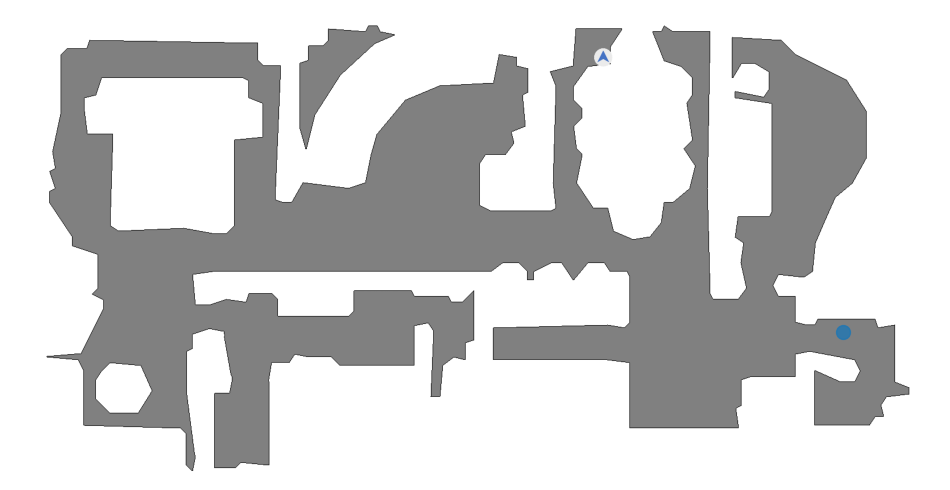

In [2]:

drawer.show_graph(env)

In [11]:
env.step([{
            "rl_pred": 1,
            "lstm_h": np.zeros((config["hid_dim_l"],), np.float32),
            "lstm_c": np.zeros((config["hid_dim_l"],), np.float32),
        }])

[19:17:01:307043]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(1.54075, 0.072447, -4.69139) ], rotQuat[ Vector(0.965926, 0, 0.258819, 0) ]
[19:17:01:307155]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[19:17:01:307180]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator


([{'camera': array([[[ 76,  64,  47, 255],
           [ 77,  64,  47, 255],
           [ 69,  58,  37, 255],
           ...,
           [176, 153, 121, 255],
           [171, 148, 117, 255],
           [173, 150, 119, 255]],
   
          [[ 78,  67,  49, 255],
           [ 79,  67,  50, 255],
           [ 72,  62,  40, 255],
           ...,
           [171, 148, 117, 255],
           [171, 148, 117, 255],
           [174, 151, 120, 255]],
   
          [[ 85,  73,  53, 255],
           [ 82,  69,  52, 255],
           [ 78,  67,  44, 255],
           ...,
           [172, 151, 120, 255],
           [172, 151, 120, 255],
           [175, 154, 123, 255]],
   
          ...,
   
          [[ 80,  68,  52, 255],
           [ 74,  63,  47, 255],
           [ 61,  52,  35, 255],
           ...,
           [117, 101,  78, 255],
           [117, 101,  78, 255],
           [116, 101,  80, 255]],
   
          [[ 79,  67,  51, 255],
           [ 73,  61,  43, 255],
           [ 62,  54,  36, 25

In [2]:

from_pos = np.array([-7.9527445 ,  0.072447  , -0.17115453])
to_pos = np.array([-1.7309015,  0.072447 , -1.292166 ])

path = habitat_sim.ShortestPath()
path.requested_start = from_pos
path.requested_end = to_pos
found_path = env._sim.pathfinder.find_path(path)
path_results = (found_path, path.geodesic_distance, path.points)

In [3]:
path.geodesic_distance

7.62939453125

In [4]:
# 我去这个就太棒了，选取的是最短的直线距离，每一次大转弯都记录一个点
path.points

[array([-7.9527445 ,  0.072447  , -0.17115453], dtype=float32),
 array([-8.34344  ,  0.072447 , -0.1920209], dtype=float32),
 array([-8.39344  ,  0.072447 , -0.7420211], dtype=float32),
 array([-8.04344  ,  0.072447 , -0.7920213], dtype=float32),
 array([-1.7309015,  0.072447 , -1.292166 ], dtype=float32)]

[array([-7.9527445 ,  0.072447  , -0.17115453], dtype=float32), array([-8.34344  ,  0.072447 , -0.1920209], dtype=float32), array([-8.39344  ,  0.072447 , -0.7420211], dtype=float32), array([-8.04344  ,  0.072447 , -0.7920213], dtype=float32), array([-1.7309015,  0.072447 , -1.292166 ], dtype=float32)]
[364.0695571899414, 325.0, 319.9999809265137, 355.0000190734863, 986.253833770752]


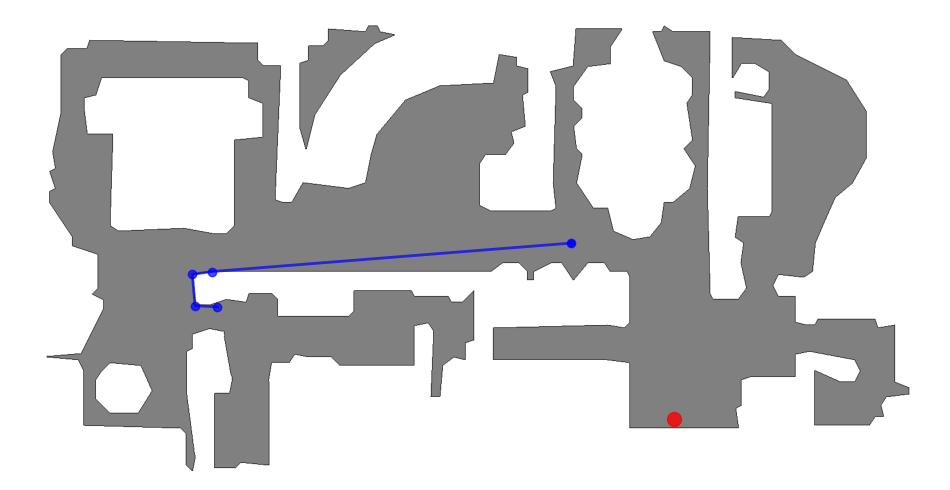

In [5]:
drawer = Draw()
output_dir = './output_images'
sound_pose = env.get_source_pos()
agent_point = path.points
print(agent_point)
image_filename = f"{output_dir}/path_graph_{1}.png"
drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)

In [ ]:
# 1. 获取到agent 和env中的声源位置
# 2. 获取到整个路径点
# 3. 进行路径点的判断，选取合适的位置插入点
# 4. 每两个点之间都选取一个中点，r = 1/2 * np.linalg.norm(path.points[x] - path.points[x+1])

In [6]:
def angle_between_points(from_pos, mid_pos, to_pos):
    
    # 计算向量 BA 和 BC
    one_vector = mid_pos - from_pos
    two_vector = to_pos - from_pos

    # 计算点积
    dot_product = np.dot(one_vector, two_vector)

    # 计算向量的模长
    norm_BA = np.linalg.norm(one_vector)
    norm_BC = np.linalg.norm(two_vector)

    # 计算余弦值，并用 arccos 求夹角（弧度）
    cos_theta = dot_product / (norm_BA * norm_BC)
    theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # 避免浮点误差导致的超出范围

    # 角度转换
    angle = np.degrees(theta)
    
    return angle


In [7]:
def mid_point(agent_point_from ,agent_point_to  ,r):
    while True:
        rand_pos = env._sim.pathfinder.get_random_navigable_point_near(agent_point_from , radius = r)
        if (
            np.linalg.norm(rand_pos - agent_point_from) > r - 0.5
            and np.linalg.norm(rand_pos - agent_point_from) < r + 0.5  # 圆环的空间
            and angle_between_points( agent_point_from , rand_pos , agent_point_to) > 20 # 设置角度的位置
            and angle_between_points( agent_point_from , rand_pos , agent_point_to) < 40
        ):
            break
        else:
            print(f'rand_pos {rand_pos} is false')
    return rand_pos

In [8]:
def insert_list_evenly(list1, list2):
    result = []
    len1, len2 = len(list1), len(list2)
    
    for i in range(len2):  # 插入 4 个元素
        result.append(list1[i])
        result.append(list2[i])  # 插入 list2 对应的元素
    
    result.extend(list1[len2:])  # 加上剩余的 list1 元素
    return result

In [9]:
# path_points
length  = len(path.points)
insert_points = []
for index , value in enumerate(path.points):
    print(index)
    if index < length - 1:
        r = 1/2 * (np.linalg.norm(path.points[index] - path.points[index+1]))
        point  = mid_point(path.points[index] , path.points[index+1] , r)
        print(f"插入一个元素{point}")
        insert_points.append(point)
result_point = insert_list_evenly(path.points , insert_points)

0
rand_pos [-7.924118    0.072447   -0.02511246] is false
rand_pos [-8.003881    0.072447   -0.04312896] is false
rand_pos [-7.7640886  0.072447  -0.1308935] is false
rand_pos [-7.8361135   0.072447   -0.14534098] is false
rand_pos [-8.066302    0.072447   -0.07828406] is false
rand_pos [-7.820383    0.072447   -0.09391855] is false
rand_pos [-7.8748035   0.072447   -0.20763096] is false
rand_pos [-7.8220654   0.072447   -0.03436414] is false
rand_pos [-8.0198765e+00  7.2447002e-02  1.4091134e-03] is false
rand_pos [-8.02362    0.072447  -0.0993659] is false
rand_pos [-7.8770614   0.072447   -0.19488442] is false
rand_pos [-7.8659678   0.072447   -0.03906085] is false
rand_pos [-7.783274    0.072447   -0.15621498] is false
rand_pos [-7.845655    0.072447   -0.05410087] is false
rand_pos [-8.011905    0.072447   -0.08900829] is false
rand_pos [-7.9540153   0.072447   -0.10174635] is false
rand_pos [-8.108656    0.072447   -0.12968731] is false
插入一个元素[-8.076327    0.072447   -0.08354774]

In [10]:
insert_points

[array([-8.076327  ,  0.072447  , -0.08354774], dtype=float32),
 array([-8.3798275 ,  0.072447  , -0.26833335], dtype=float32),
 array([-8.290903  ,  0.072447  , -0.82688785], dtype=float32),
 array([-5.5190735,  0.072447 ,  0.501855 ], dtype=float32)]

In [11]:
result_point

[array([-7.9527445 ,  0.072447  , -0.17115453], dtype=float32),
 array([-8.076327  ,  0.072447  , -0.08354774], dtype=float32),
 array([-8.34344  ,  0.072447 , -0.1920209], dtype=float32),
 array([-8.3798275 ,  0.072447  , -0.26833335], dtype=float32),
 array([-8.39344  ,  0.072447 , -0.7420211], dtype=float32),
 array([-8.290903  ,  0.072447  , -0.82688785], dtype=float32),
 array([-8.04344  ,  0.072447 , -0.7920213], dtype=float32),
 array([-5.5190735,  0.072447 ,  0.501855 ], dtype=float32),
 array([-1.7309015,  0.072447 , -1.292166 ], dtype=float32)]

In [12]:
path.points

[array([-7.9527445 ,  0.072447  , -0.17115453], dtype=float32),
 array([-8.34344  ,  0.072447 , -0.1920209], dtype=float32),
 array([-8.39344  ,  0.072447 , -0.7420211], dtype=float32),
 array([-8.04344  ,  0.072447 , -0.7920213], dtype=float32),
 array([-1.7309015,  0.072447 , -1.292166 ], dtype=float32)]

[array([-8.076327  ,  0.072447  , -0.08354774], dtype=float32), array([-8.3798275 ,  0.072447  , -0.26833335], dtype=float32), array([-8.290903  ,  0.072447  , -0.82688785], dtype=float32), array([-5.5190735,  0.072447 ,  0.501855 ], dtype=float32)]
[351.7112731933594, 321.36125564575195, 330.2536964416504, 607.4366569519043]


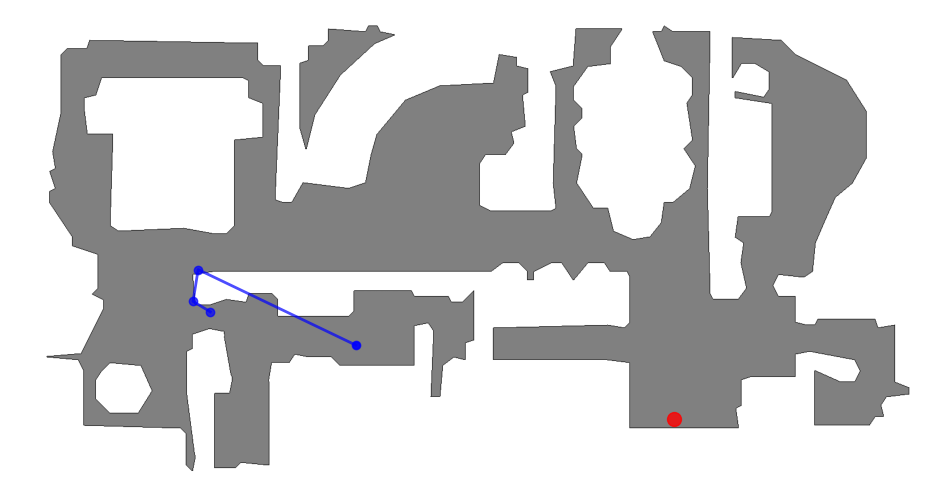

In [13]:
drawer = Draw()
output_dir = './output_images'
sound_pose = env.get_source_pos()
agent_point = insert_points
print(agent_point)
image_filename = f"{output_dir}/path_graph_{1}.png"
drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)

[array([-7.9527445 ,  0.072447  , -0.17115453], dtype=float32), array([-8.076327  ,  0.072447  , -0.08354774], dtype=float32), array([-8.34344  ,  0.072447 , -0.1920209], dtype=float32), array([-8.3798275 ,  0.072447  , -0.26833335], dtype=float32), array([-8.39344  ,  0.072447 , -0.7420211], dtype=float32), array([-8.290903  ,  0.072447  , -0.82688785], dtype=float32), array([-8.04344  ,  0.072447 , -0.7920213], dtype=float32), array([-5.5190735,  0.072447 ,  0.501855 ], dtype=float32), array([-1.7309015,  0.072447 , -1.292166 ], dtype=float32)]
[364.0695571899414, 351.7112731933594, 325.0, 321.36125564575195, 319.9999809265137, 330.2536964416504, 355.0000190734863, 607.4366569519043, 986.253833770752]


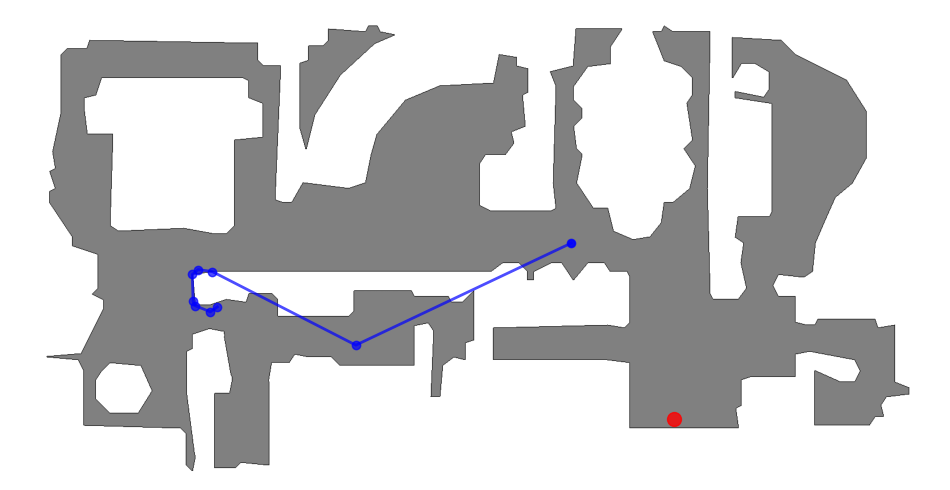

In [14]:
drawer = Draw()
output_dir = './output_images'
sound_pose = env.get_source_pos()
agent_point = result_point
print(agent_point)
image_filename = f"{output_dir}/path_graph_{1}.png"
drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)

[array([ 2.4140835,  0.072447 , -3.3045335], dtype=float32), array([ 1.3565598 ,  0.072447  , -0.49202108], dtype=float32), array([ 1.2065601 ,  0.072447  , -0.29202127], dtype=float32), array([-0.79343987,  0.072447  ,  0.20797873], dtype=float32), array([-1.3361979 ,  0.072447  ,  0.19951062], dtype=float32)]
[1400.752353668213, 1294.9999809265137, 1280.0000190734863, 1080.0000190734863, 1025.724220275879]


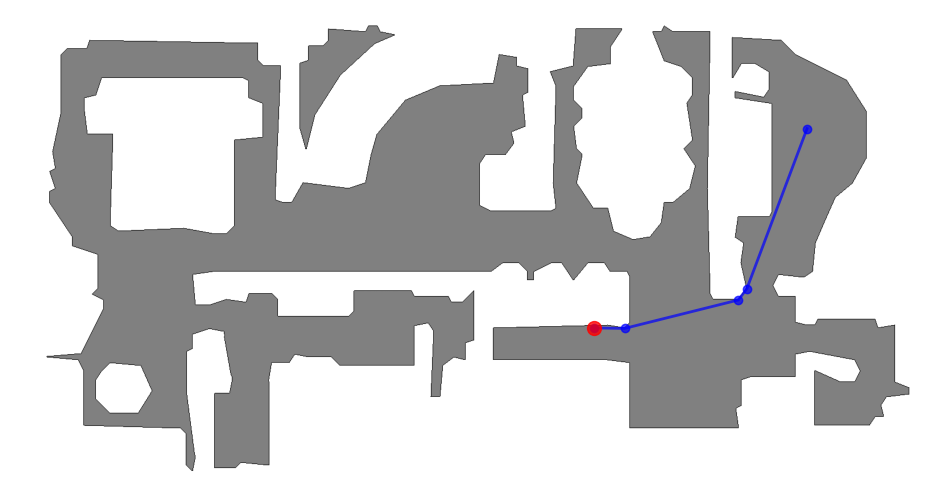

In [54]:
drawer = Draw()
output_dir = './output_images'
sound_pose = env.get_source_pos()
agent_point = path.points
print(agent_point)
image_filename = f"{output_dir}/path_graph_{1}.png"
drawer.show_path_graph(env , sound=sound_pose ,agent=agent_point ,image_filename=image_filename)